## Introduction to Power Network Analysis with Pandapower
##### Xiangyue Wang, Thomas Morstyn

**Pandapower** is a popular open-sourced python package for power system modeling and optimization. Its name originates from the data analysis library, **pandas**, and the power flow solver library, **PYPOWER**. Pandapower combines the data structure of the former with solvers from the latter to:

- conduct static analysis of **three-phase distribution systems**, which are commonly found in Europe
- solve **AC and DC optimal power flow** problems
- conduct state estimation, static short-circuit simulation, and topological search.



As of Feburary, 2025, Pandapower **cannot** analyse distribution grids with unsymmetrical power lines design, such as the feeder design common in North America. It also cannot solved unbalanced power flow problems and conduct dynamic short-circuit simulation. As you will see later in this tutorial, it also has some difficulties dealing with multi-time coupled variables, but we can use it in combination with other optimization software to overcome its shortcomings.

In this notebook, we will walk you through how to use pandapower for power flow optimization.

### Installation

We recommend running this tutorial in an Anaconda environment to avoid missing dependencies.

In [ ]:
%pip install "pandapower[all]"

The command above could result in an error if you are starting a new virtual environment without nothing else installed. In that case, use the **requirements.txt** file I included in the repository to install pandapower together with some necessary packages such as numpy and pandas. For the plotting function to work, you also need to install igraph, which is included in the requirements.txt.

In [5]:
# pip install requirements.txt

### 1. First Example: Power Flow Modeling Review

Recall that electric systems almost everywhere involve sinusoidally varying AC voltages and currents. In other words,
$$ V(t) = V_{max} sin(\omega t+\theta_v)$$
$$ I(t) = I_{max} sin(\omega t+\theta_i)$$
where $\theta_v, \theta_i$ are phase angles, and $\omega$ is the angular frequency (50 Hz or 100 times of direction change per second for Europe). We are interested in steady state conditions at this fixed frequency since this is where normal power system operation takes place. **Specifically, we wish to find the voltage magnitude and voltage angle across the network given a set of generators and loads.**

In DC Power Flow Modeling, we are particularly concerned with the voltage angle difference between buses. For convenience, we set all voltage angles as the difference relative to a reference bus (called the **slack bus**, normally the largest generator for transmission network), whose angle is conventionally set to zero.

For example, if you have two voltage signals:

Bus 1 voltage: $V_1=V_{max}sin⁡(ωt)$

Bus 2 voltage: $V_2=V_{max}sin⁡(ωt−10\degree)$

The voltage angle of Bus 2 is -10° relative to Bus 1, or $V_2 = V_{max}\angle -10\degree$.
Note that voltage angles aren't physical angles of objects. Instead, they're determined indirectly using Phasor Measurement Units (PMUs), which measure precise time-stamped voltage and current waveforms at buses. Just as water moves from higher to lower pressure, electric power flows from higher voltage angle (sources) to lower voltage angle (loads). 

In pandapower, it is common to set the **external grid** as the reference slack bus. Any given grid can import or export electricity to the external grid (at a price we need to set), providing flexibility in power balancing.

In DC Power Flow, we assume nodes have small voltage angle differences and small voltage drops (typically true for transmission) in order to linearize the sinusoidal AC voltage. For DC power flow, the power flow from bus k to j is

$$P_{kj} = \frac{1}{x_{kj}}(\theta_k - \theta_j) = B_{kj}(\theta_k - \theta_j)$$

where $x_{kj}$ is the line reactance and $B_{kj}$ is the line suceptance, or the kj-th entry of the admittance matrix.

Recall this example from the lectures:

![example_1.png](images/example_1.png)

where **pu** stands for **per unit** to simplify the calculation. Let's try to replicate this grid in pandapower. 
### 1a. How to Make a Grid in Pandapower
First, we import pandapower as **pp** and create an empty network using **pp.create_empty_network()**.

In [1]:
import pandapower as pp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandapower.plotting as plot

# Create an empty network
net1 = pp.create_empty_network()
print('network created')

network created


Then, we create the buses using **create_bus**. Since the example is in a per unit system with no base unit specified, we will go ahead and assume the base voltage is 110 kV and the base apparent power is 100 MVA.

In [2]:
# Set base values for the per unit system
base_kV = 110.0 # Base voltage in kV
base_MVA = 100  # Base apparent power

#Create the buses
bus1 = pp.create_bus(net1, vn_kv=base_kV, name="Bus 1")
bus2 = pp.create_bus(net1, vn_kv=base_kV, name="Bus 2")
bus3 = pp.create_bus(net1, vn_kv=base_kV, name="Bus 3")

#Show the bus table
net1.bus 

,name,vn_kv,type,zone,in_service,geo
0,Bus 1,110.0,b,None,True,None
1,Bus 2,110.0,b,None,True,None
2,Bus 3,110.0,b,None,True,None


Now, let's add the generators using **create_gen**. The diagram shows two generators. Since bus 1 is the slack bus, we will connect the external grid to bus 1 and set the voltage magnitude (vm_pu) as 1 per unit. 

From the problem, we know that generator 2 has active power (p_mw) of 1 per unit and reactive power (q_mvar) of 0.5 per unit. We don't know the active power about the generator at the slack bus, generator 1, but we still need to give it an initial guess. Zero is normally fine, because pandapower will calculate the p value for slack during the power flow. 
| Parameter |   Abbreviation |
| -------- | ------- |
| active power (MW)  | p_mw    |
| minimum active power (MW)  | min_p_mw    |
| maximum active power (MW) | max_p_mw    |
| reactive power (MW)   | q_mvar   |

In [3]:
#Create the external grid at bus 1
ext = pp.create_ext_grid(net1, bus=bus1, vm_pu=1.0, name="Slack Bus")

#Create the generators at bus 1 and 2
pp.create_gen(net1, bus=bus1, p_mw=0, min_p_mw=0, max_p_mw=base_MVA, name="Generator 1")
pp.create_gen(net1, bus=bus2, p_mw=base_MVA, q_mvar=0.5*base_MVA, min_p_mw=0, max_p_mw=base_MVA, name="Generator 2")

#Show the generator table
net1.gen

,name,bus,p_mw,vm_pu,sn_mva,min_q_mvar,max_q_mvar,scaling,slack,controllable,id_q_capability_characteristic,reactive_capability_curve,curve_style,in_service,slack_weight,type,min_p_mw,max_p_mw,q_mvar
0,Generator 1,0,0.0,1.0,NaN,NaN,NaN,1.0,False,True,<NA>,False,NaN,True,0.0,None,0.0,100.0,NaN
1,Generator 2,1,100.0,1.0,NaN,NaN,NaN,1.0,False,True,<NA>,False,NaN,True,0.0,None,0.0,100.0,50.0


Now, let's add the loads. From the problem, we know that the load connected to bus 3 has active power of 2 per unit and reactive power of 0.5 per unit. 

In [4]:
#Create the load at bus 3
pp.create_load(net1, bus=bus3, p_mw=2*base_MVA, q_mvar=0.5*base_MVA, name="L3")

#Show the load table
net1.load

,name,bus,p_mw,q_mvar,const_z_p_percent,const_i_p_percent,const_z_q_percent,const_i_q_percent,sn_mva,scaling,in_service,type
0,L3,2,200.0,50.0,0.0,0.0,0.0,0.0,NaN,1.0,True,wye


Lastly, let's add the lines. From the problem, we know that
$$z_{12} = 0.001 + j0.01 pu$$
$$z_{13} = 0.001 + j0.01 pu$$

meaning that each line has resistance (R) of 0.001 pu and reactance (X) of 0.01 pu. To add those lines, we need to convert per unit to Ohms by determining the base impedance:

$$Z_{base} = \frac{V^2_{base}}{S_{base}}$$

In [5]:
# Compute Base Impedance
z_base = base_kV**2 / base_MVA  # in Ohms

# Line Impedances in Ohms
r_ohm = 0.001*z_base
x_ohm = 0.01*z_base

# Create the specific line used in Example 1
example1_line = {"r_ohm_per_km": r_ohm, "x_ohm_per_km": x_ohm, "c_nf_per_km": 10, "max_i_ka": 0.4, "type": "cs"}
pp.create_std_type(net1, name="example1_line", data=example1_line, element="line")
pp.available_std_types(net1, element="line")

length_km = 1  # nominal length

pp.create_line(net1, from_bus=bus1, to_bus=bus2, length_km=length_km, std_type="example1_line", name="line12")
pp.create_line(net1, from_bus=bus1, to_bus=bus3, length_km=length_km, std_type="example1_line", name="line13")

#Show the line table
net1.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo
0,line12,example1_line,0,1,1.0,0.121,1.21,10.0,0.0,0.4,1.0,1,cs,True,None
1,line13,example1_line,0,2,1.0,0.121,1.21,10.0,0.0,0.4,1.0,1,cs,True,None


Now, let's have a look at the grid we created. Note that you need to pip install igraph.

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


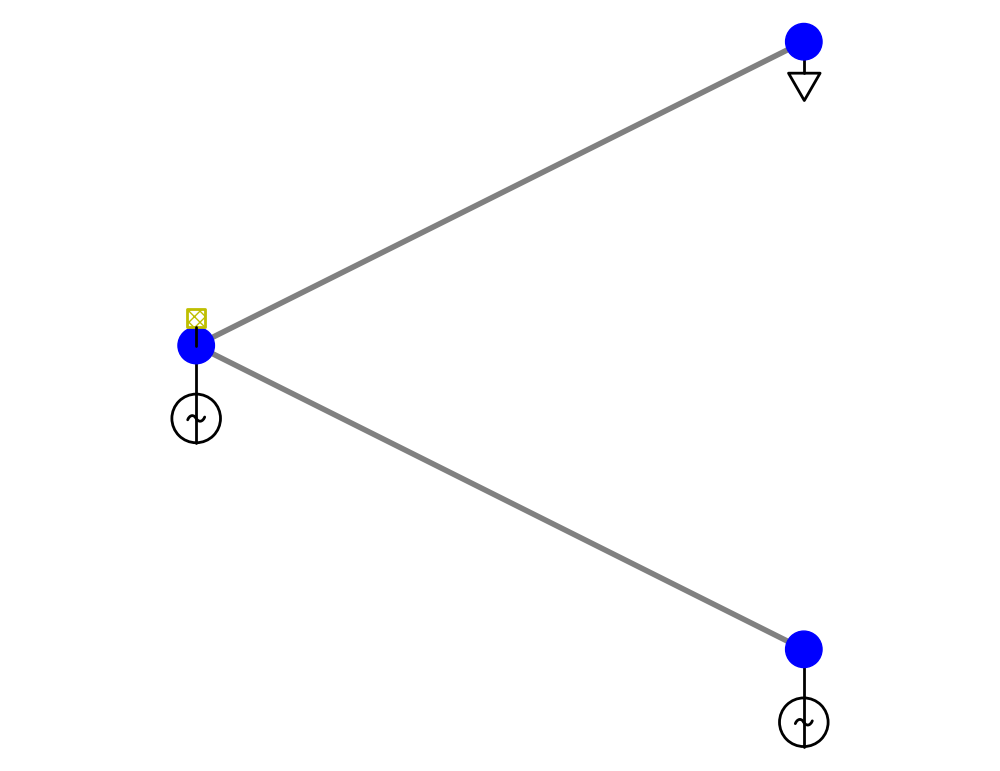

<Axes: >

In [6]:
#Show the Example 1 grid
plot.simple_plot(net1, show_plot=True, plot_loads=True, plot_gens=True, gen_size =4, load_size=3, line_width=4, bus_size=3)

### 1b. Analytical Solution

Let's go back to the question:

![example_1.png](images/example_1.png)

Recall how we would solve this problem analytically:

$$
\begin{bmatrix}
P_1\\
P_2\\
\vdots\\
P_N
\end{bmatrix}=\textbf{B}\begin{bmatrix}
\theta_1\\
\theta_2\\
\vdots\\
\theta_N
\end{bmatrix}=
\begin{bmatrix}
B_{12} + B_{13} + \dots + B_{1N} & -B_{12}                 & \dots & -B_{1N}\\
-B_{21}                          & B_{21} + B_{22} + \dots + B_{2N} & \dots & -B_{2N}\\
\vdots                           & \vdots                           & \ddots & \vdots\\
-B_{N1}                          & -B_{N2}                          & \dots & B_{N1} + B_{N2} + \dots
\end{bmatrix}
\begin{bmatrix}
\theta_1\\
\theta_2\\
\vdots\\
\theta_N
\end{bmatrix}
$$

where $B_{ij} = \frac{1}{x_{ij}}$

#### Question 1.1 | Write the admittance matrix B for this problem and solve analytically.

Remember that you can remove the slack bus row and column (row 1 and column 1) from B since we set the voltage angle for slack bus as 0 degree. If you don't do it, B will not be invertible. For the final answer, add the $P_1$ and $\theta_1$ back to P and theta vectors and convert theta from radian to degrees. 

In [7]:
#Initialize
B = np.zeros(shape=(3,3))
theta = np.zeros(shape=(3,1))
P = np.zeros(shape=(3,1))

#Enter your answer here
B = np.array([[1/0.01 +1/0.01, -1/0.01, -1/0.01], 
              [-1/0.01, 1/0.01,  0], 
              [-1/0.01, 0,  1/0.01]])
B = B[1:, 1:]
P = np.array([[1], [-2]]) 
theta = np.linalg.pinv(B) @ P
P = np.insert(P, 0, 1).reshape(-1, 1)
theta = np.insert(theta, 0, 0).reshape(-1, 1)
theta = theta * 180/np.pi

#Check Answer
print ('P is correct') if np.array_equal(P.flatten(),([1,1,-2])) else print ('P is wrong.')
print ('theta is correct') if np.allclose(theta.flatten(), ([0,0.5729578,-1.14591559])) else print ('Theta is wrong.')


P is correct
theta is correct


### 1c. Numerical Solver
Now, we will solve the DC power flow using pandapower's DC power flow solver.

In [8]:
#DC Power Flow
pp.rundcpp(net1)
print(net1.res_bus)

   vm_pu  va_degree   p_mw  q_mvar
0    1.0   0.000000 -100.0     NaN
1    1.0   0.572958 -100.0     NaN
2    1.0  -1.145916  200.0     NaN


We can also solve the same grid using the Balanced AC Power flow function.

In [9]:
# Run balanced AC power flow
pp.runpp(net1)
print(net1.res_bus)

      vm_pu  va_degree        p_mw     q_mvar
0  1.000000   0.000000 -100.532105 -64.754756
1  1.000000   0.578405 -100.000000   9.509458
2  0.992758  -1.125501  200.000000  50.000000


#### Question 1.2 | Interpret the results
Remember that for p_mw, negative is generation and positive is load.

Gnerator 1 and generator 2 each supplies about 100 MW of power to meet the 200 MW of demand at bus 3.

#### Question 1.3 | How do the DC and AC power flow results compare?

They are roughly the same.

#### Question 1.4 | Why doesn't the DC power flow have q_mvar results?

DC OPF only keeps the real power balance equation, which is linear. Reactive power equation is nonlinear, hence it is discarded.

### 2. Second Example: Optimal Power Flow
Optimal power flow problem asks us to balance the grid in such a way that optimize an objective function. We could be minimizing cost, carbon emission, or a combination of any other values that we care about. To start, let's simply assume that we only care about minimizing cost. We will look at another example from the lectures. 
![example_2.png](images/example_2.png)

This time we are trying to optimize the power flow based on the cost of generation for each generator. Again, the problem didn't tell us much about the generators. To make things interesting, let's assume each of them has maximum power of 150 MW.

We will need to add the cost function for each generator, as wel as the cost of exporting/importing electricity from the grid. We can do so using **pp.create_poly_cost**. We know the cost of generation for each generator, but not for our external grid. Let's assume that it costs 75 pounds per MWh, which is the typical UK price at this moment.

### 2a. Build the grid
#### Question 2.1 | Try creating an empty network and adding the generators and load yourself.


In [10]:
# Create an empty network
net2 = pp.create_empty_network()

# Set base values for the per unit system
base_kV = 110 # Base voltage in kV
base_MVA = 150 # Base apparent power

#Create the buses
b1 = pp.create_bus(net2, vn_kv=base_kV, name="Bus 1")
b2 = pp.create_bus(net2, vn_kv=base_kV, name="Bus 2")
b3 = pp.create_bus(net2, vn_kv=base_kV, name="Bus 3")

# Create external grid (slack bus at Bus 1)
ext = pp.create_ext_grid(net2, bus=b1, vm_pu=1.0, name="Slack Bus")

#Create the generators 
gen1 = pp.create_gen(net2, bus=b1, p_mw=0, min_p_mw=0, max_p_mw=base_MVA, name="Generator 1")
gen2 = pp.create_gen(net2, bus=b2, p_mw=0, min_p_mw=0, max_p_mw=base_MVA, name="Generator 2")
gen3 = pp.create_gen(net2, bus=b3, p_mw=0, min_p_mw=0, max_p_mw=base_MVA, name="Generator 3")

# Add generator costs
pp.create_poly_cost(net2, element=gen1, et='gen', cp1_eur_per_mw=20)
pp.create_poly_cost(net2, element=gen2, et='gen', cp1_eur_per_mw=30)
pp.create_poly_cost(net2, element=gen3, et='gen', cp1_eur_per_mw=100)
pp.create_poly_cost(net2, element=ext, et='ext_grid', cp1_eur_per_mw=75)

#Create the loads
pp.create_load(net2, bus=b2, p_mw=3*base_MVA, q_mvar=0.5*base_MVA, name="L2")

#Show buses
net2.bus


,name,vn_kv,type,zone,in_service,geo
0,Bus 1,110.0,b,None,True,None
1,Bus 2,110.0,b,None,True,None
2,Bus 3,110.0,b,None,True,None


Now, we need to add the lines with the specific powerflow limits. To add the limits, we need to convert the power limit into current limit. Recall that apparent power (S) in a three-phase system is given by
$$S = \sqrt{3}VI$$
$$I = \sqrt{3}VS$$
#### Question 2.2 | Create a function **mw_to_ka** in the code below.

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


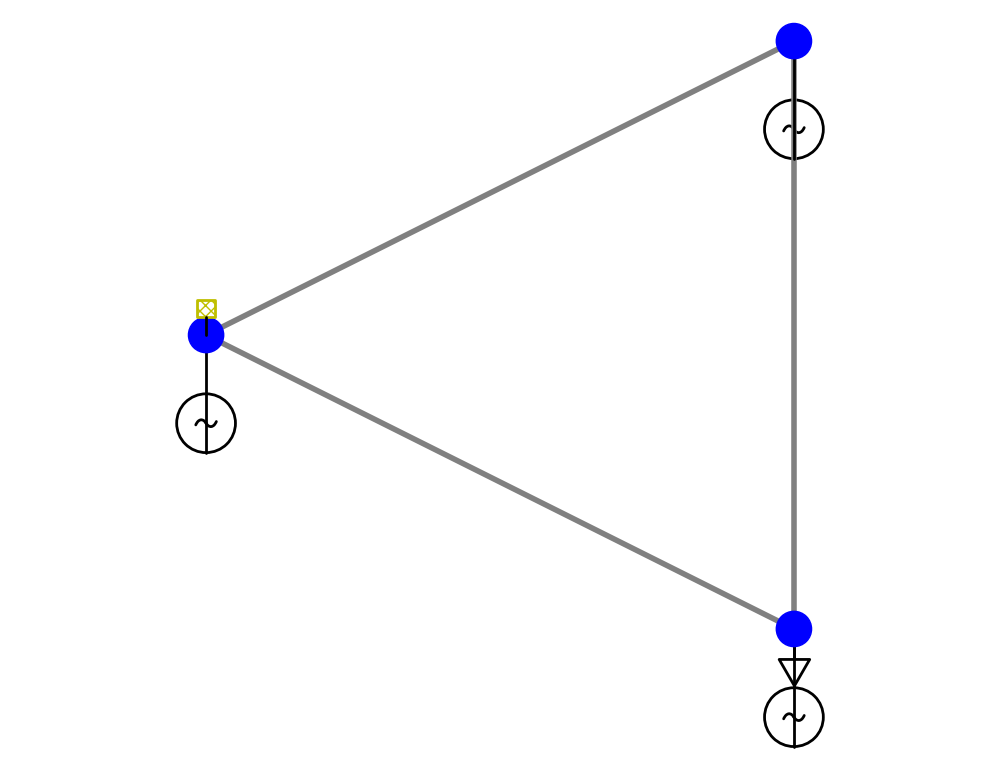

<Axes: >

In [11]:
# Compute Base Impedance
z_base = base_kV**2 / base_MVA  # in Ohms

# Line Impedances in Ohms
r_ohm = 0 # Since we don't have the info, let's assume we have negligible resistance
x_ohm = 0.5*z_base

length_km = 1  # nominal length

#Convert line flow limits from MW to kA (approx)
def mw_to_ka(p_mw, v_kv=base_kV):
    return p_mw / (v_kv * (3)**0.5)

# Add lines with limits
pp.create_line_from_parameters(net2, b1, b2, length_km=1,
    r_ohm_per_km=r_ohm, x_ohm_per_km=x_ohm, c_nf_per_km=0,
    max_i_ka=mw_to_ka(200), name="line12")

pp.create_line_from_parameters(net2, b1, b3, length_km=1,
    r_ohm_per_km=r_ohm, x_ohm_per_km=x_ohm, c_nf_per_km=0,
    max_i_ka=mw_to_ka(200), name="line13")

pp.create_line_from_parameters(net2, b2, b3, length_km=1,
    r_ohm_per_km=r_ohm, x_ohm_per_km=x_ohm, c_nf_per_km=0,
    max_i_ka=mw_to_ka(50), name="line23")

#Show the Example 2 grid
plot.simple_plot(net2, show_plot=True, plot_loads=True, plot_gens=True, gen_size =5, load_size=3, line_width=4, bus_size=3)

### 2b. DC and AC OPF

We will run DC and AC OPF with the pandapower function **pp.rundcopp** and **pp.runopp**.

#### Question 2.3 | In the code cells below, Run AC and DC OPF.

In [12]:
# Run DC Optimal Power Flow
pp.rundcopp(net2)
print("DC OPF")
print(net2.res_bus)
print("Optimal Cost is", net2.res_cost)


DC OPF
   vm_pu  va_degree          p_mw  q_mvar  lam_p  lam_q
0    1.0   0.000000 -3.000000e+02     NaN   75.0    0.0
1    1.0 -38.197186  3.000000e+02     NaN   75.0    0.0
2    1.0 -19.098593 -8.081042e-08     NaN   75.0    0.0
Optimal Cost is 18750.000006055787


In [13]:
# Run AC Optimal Power Flow
pp.runopp(net2)
print("AC OPF")
print(net2.res_bus)
print("Optimal Cost is", net2.res_cost)

AC OPF
      vm_pu     va_degree        p_mw     q_mvar  lam_p         lam_q
0  1.000000 -3.768791e-21 -299.999991 -91.316784   75.0  4.573450e-20
1  0.999985 -4.070736e+01  300.000011 -91.303467   75.0  1.665957e-19
2  1.000008 -2.035351e+01   -0.000020 -37.470983   75.0  3.752462e-20
Optimal Cost is 18750.001502544397


#### Question 2.4 | How do the DC and AC OPF results compare?

They are roughly the same.

### 2c. Solve Using PICOS

For comparison, we can also try to solve the problem using **PICOS**, a python convex optimization package.

![example_2.png](images/example_2.png)

Our decision variables are the generator outputs, $P_{g1}, P_{g2}$, and $P_{g3}$ as well as the voltage angles $\theta_2, \theta_3$.


In [ ]:
%pip install picos

In [15]:
import picos as pic

# Initialize the optimization problem.
prob = pic.Problem()

# Add decision variables: (name, size)
Pg1    = pic.RealVariable("Pg1") 
Pg2    = pic.RealVariable("Pg2")
Pg3    = pic.RealVariable("Pg3")
theta2 = pic.RealVariable("theta2")
theta3 = pic.RealVariable("theta3")
print('Variables created.')

Variables created.


The objective function that we wish to minimize is the cost function:
$$C = 20P_{g1}+30P_{g2}+100P_{g3}$$

In [16]:
# Set objective function
prob.set_objective("min", 20*Pg1 + 30*Pg2 + 100*Pg3)
print('objective function created')

objective function created


Lastly, the constraints are the power flow limit:
$$P_{kj} = \frac{1}{x_{kj}}(\theta_k - \theta_j)$$

which we have to convert to constraints on $P_{g1}, P_{g2}, P_{g3}$. Looking at the graph, we can notice that for bus 1:
$$P_{g1} = P_{12} + P_{13}$$
where 
$$P_{12} = 2(\theta_1 - \theta_2) = -2\theta_2$$
and 
$$P_{13} = 2(\theta_1 - \theta_3) = -2\theta_3$$

Hence
$$P_{g1} = -2\theta_2 - 2\theta_3$$

For bus 2, we don't expect the generator to transmit power through the lines since it is right next to the load.

For bus 3, since it is the most expensive, we can assume that it is used sparingly. In other words,
$$P_{g3} = P_{31} + P_{32} = P_{32} = 2(\theta_3 - \theta_2)$$

Lastly, we have to meet the demand.
$$P_{g1} + P_{g2} + P{g3} = 300$$


We will aslo add the line limits and generator limits (which, again, we assume since the problem doesn't provide the details).

In [17]:
# Power flow constraints:
prob.add_constraint(Pg1 + 2*theta2 + 2*theta3 == 0)  # Bus 1
prob.add_constraint(Pg3 - 2*theta3 + 2*theta2 == 0)  # Bus 2
prob.add_constraint(Pg1 + Pg2 + Pg3 == 300)  # Meet Demand

# Line limits
prob.add_constraint(theta2 >= -100)  # line 12
prob.add_constraint(theta2 <= 100)  # line 12
prob.add_constraint(theta3 >= -100)  # line 13
prob.add_constraint(theta3 <= 100)  # line 13
prob.add_constraint((theta2 - theta3)>= -25)  # line 23
prob.add_constraint((theta2 - theta3)<= 25)  # line 23

# Add generation bounds: 0 <= Pg_i <= 150
prob.add_constraint(Pg1 >= 0)
prob.add_constraint(Pg1 <= 150)
prob.add_constraint(Pg2 >= 0)
prob.add_constraint(Pg2 <= 150)
prob.add_constraint(Pg3 >= 0)
prob.add_constraint(Pg3 <= 150)

#Show constraints
prob.constraints

mappingproxy({747836068: <1×1 Affine Constraint: Pg1 + 2·theta2 + 2·theta3 = 0>,
              747836069: <1×1 Affine Constraint: Pg3 - 2·theta3 + 2·theta2 = 0>,
              747836070: <1×1 Affine Constraint: Pg1 + Pg2 + Pg3 = 300>,
              747836071: <1×1 Affine Constraint: theta2 ≥ -100>,
              747836072: <1×1 Affine Constraint: theta2 ≤ 100>,
              747836073: <1×1 Affine Constraint: theta3 ≥ -100>,
              747836074: <1×1 Affine Constraint: theta3 ≤ 100>,
              747836075: <1×1 Affine Constraint: theta2 - theta3 ≥ -25>,
              747836076: <1×1 Affine Constraint: theta2 - theta3 ≤ 25>,
              747836077: <1×1 Affine Constraint: Pg1 ≥ 0>,
              747836078: <1×1 Affine Constraint: Pg1 ≤ 150>,
              747836079: <1×1 Affine Constraint: Pg2 ≥ 0>,
              747836080: <1×1 Affine Constraint: Pg2 ≤ 150>,
              747836081: <1×1 Affine Constraint: Pg3 ≥ 0>,
              747836082: <1×1 Affine Constraint: Pg3 ≤ 150>})

In [18]:
# Solve the optimization problem.
solution = prob.solve(verbosity=True)

            PICOS 2.6.2            


Problem type: Linear Program.
Searching a solution strategy.
Solution strategy:
  1. ExtraOptions
  2. CVXOPTSolver
Applying ExtraOptions.
Building a CVXOPT problem instance.
Starting solution search.
-----------------------------------
 Python Convex Optimization Solver 
    via internal CONELP solver     
-----------------------------------
     pcost       dcost       gap    pres   dres   k/t
 0:  1.3819e+04 -4.7340e+03  2e+04  2e-01  3e-16  1e+00
 1:  6.0854e+03 -1.5191e+04  3e+04  2e-01  1e-15  5e+02
 2:  7.4767e+03  6.5839e+03  1e+03  1e-02  6e-15  7e+01
 3:  7.5007e+03  7.4904e+03  1e+01  1e-04  2e-15  8e-01
 4:  7.5000e+03  7.4999e+03  1e-01  1e-06  1e-15  8e-03
 5:  7.5000e+03  7.5000e+03  1e-03  1e-08  5e-16  8e-05
 6:  7.5000e+03  7.5000e+03  1e-05  1e-10  8e-16  8e-07
Optimal solution found.
------------[ CVXOPT ]-------------
Solver claims optimal solution for feasible problem.
Applying the solution.
Applied solution is primal feasible.
Search 6.6e-01s, solve 6.9e-01s, ove

In [19]:
# Print the results.
print("Pg1 =", Pg1)
print("Pg2 =", Pg2)
print("Pg3 =", Pg3)
print("theta2 =", theta2)
print("theta3 =", theta3)
print("\nCost = ", prob.value)

Pg1 = 149.99999999815253
Pg2 = 149.9999999927594
Pg3 = 9.088092950788378e-09
theta2 = -37.50000000181016
theta3 = -37.499999997266116

Cost =  7500.000000654642


#### Question 2.5 | Does the optimal cost from PICOS match that of pandapower?

Yes.

### 3. Third Example: Great Britain Network

For our third example, let's look at a commonly used generic network available in pandapower, the Oberrhein network. We will import it from **pandapower.networks**, which contains a set of other useful grids. You can find out about them [here.](https://pandapower.readthedocs.io/en/v2.0.0/networks/power_system_test_cases.html#case-gb-network)

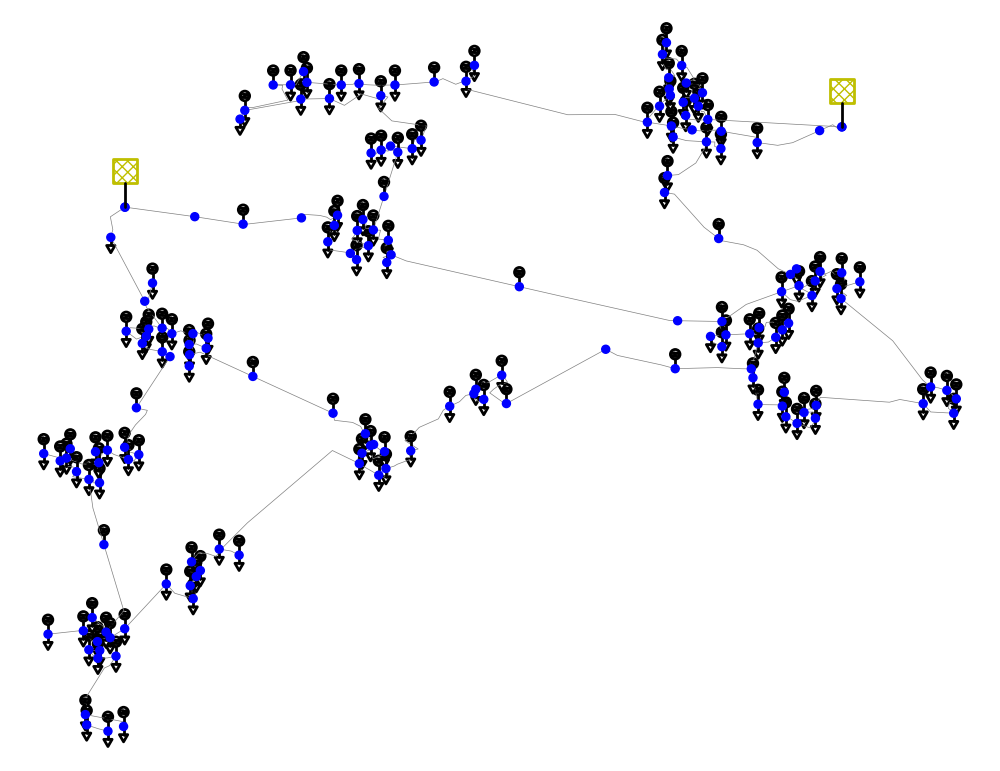

<Axes: >

In [20]:
import pandapower.networks as pn
net3 = pn.mv_oberrhein()
plot.simple_plot(net3, show_plot=True, plot_loads=True, load_size=0.6, plot_sgens=True,  sgen_size =0.6, trafo_size=0.02, line_width=0.5, bus_size=0.5)

Let's take a look at the buses.

In [174]:
net3.bus

,name,vn_kv,type,zone,in_service,geo
0,Bus 0,20.0,n,None,True,"{""coordinates"": [7.765225672614365, 48.4109158..."
1,Bus 1,20.0,n,None,True,"{""coordinates"": [7.778809539550178, 48.4098706..."
2,Bus 2,20.0,n,None,True,"{""coordinates"": [7.779195765893586, 48.4120381..."
3,Bus 3,20.0,n,None,True,"{""coordinates"": [7.775204689771646, 48.4061033..."
4,Bus 4,20.0,n,None,True,"{""coordinates"": [7.76606484746611, 48.41242444..."
...,...,...,...,...,...,...
315,Bus 174,20.0,n,None,True,"{""coordinates"": [7.749908553830717, 48.3884998..."
316,Bus 175,20.0,n,None,True,"{""coordinates"": [7.753125163009409, 48.3319834..."
317,Bus 176,20.0,n,None,True,"{""coordinates"": [7.879041696902467, 48.4157260..."
318,Bus 177,110.0,b,None,True,"{""coordinates"": [7.7615333943715035, 48.439874..."


#### Question 3.1 | Fill in the code cells below. Solve both DC and AC Power flow on this grid.

In [26]:
#DC Power Flow
pp.rundcpp(net3)
print("DC OPF")
print(net3.res_bus)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


DC OPF
     vm_pu   va_degree    p_mw    q_mvar
0      1.0 -156.953119   0.240  0.048734
1      1.0 -156.956826   0.150  0.030459
2      1.0 -156.920553   0.150  0.030459
3      1.0 -156.985179   0.150  0.030459
4      1.0 -156.932020   0.150  0.030459
..     ...         ...     ...       ...
315    1.0 -157.249759   0.240  0.048734
316    1.0 -157.939142   0.150  0.030459
317    1.0 -156.806618   0.000  0.000000
318    1.0    0.000000 -20.274 -4.653035
319    1.0 -154.968285   0.000  0.000000

[179 rows x 4 columns]


In [27]:
#AC Power Flow
pp.runpp(net3)
print("DC OPF")
print(net3.res_bus)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


DC OPF
        vm_pu   va_degree       p_mw    q_mvar
0    1.009473 -156.778921   0.240000  0.048734
1    1.009354 -156.783526   0.150000  0.030459
2    1.010306 -156.753059   0.150000  0.030459
3    1.008611 -156.807492   0.150000  0.030459
4    1.010021 -156.761493   0.150000  0.030459
..        ...         ...        ...       ...
315  1.001721 -157.022972   0.240000  0.048734
316  0.983367 -157.616827   0.150000  0.030459
317  0.999822 -156.622559   0.000000  0.000000
318  1.000000    0.000000 -20.863017 -4.653035
319  1.028804 -154.943953   0.000000  0.000000

[179 rows x 4 columns]


With a grid this big, it's very hard to analyze the results from the table alone. Let's explore the outputs a bit more using plotly.

In [32]:
import pandapower.plotting.plotly as plotly
plotly.pf_res_plotly(net3)

ImportError: Some pandapower functionality use optional python packages.
_create_node_trace() requires 'plotly' which could not all be imported.
To install pandapower with all optional dependencies, type `pip install pandapower["all"]`.

#### Question 3.2 | By looking at the graph, what do you observe?




The middle left portion of the grid is the most active, with lots of power flow around the external grid at bus 177. The lines surrounding the other external grid at bus 38 also have relatively more activity than the rest of the grid.

#### If we add more generation to bus 176, how would that change the power flow?

There are already a static generator present at almost every bus, and the generators at the middle right of the grid seem adequate in meeting the demands, hence we expect the generator to transmit electricity mostly to the middle left, where there're more activities. 

### 4. Multi-period Optimization with Energy Storage
To conclude, let's take everything we've learned so far and attempt to operate a small but more realistic grid for a day.

Since OPF is a problem that needs to be solved continuously due to varying demand and supply (for variable sources such as wind and solar), the real-world scenario asks us to solve a time series of OPF problems. The OPF problem is solved for each specified time step (say, 15 min) with separate decision variables for each time interval. Since we are operating the grid for a day using 15-min intervals, we need to solve the OPF 96 times. 

Furthermore, let's add battery storage to the grid. The battery storage variables will be coupled with every time step throughout the day. Our objective function will then need to include the battery storage degradation cost, and the constraints will need to include energy storage constraints.

Assuming linear storage degradation cost, $\sum_{t=1}^T c^{deg}(P_t^{ch} + P_t^{dis})$, the objective function becomes:

$$\sum_{t=1}^T\sum_{i=1}^Nc_{it}^gP_{it}^g+c_i^{deg}(P_{it}^{ch}+P_{it}^{dis})$$

where 

$P_t^{ch}$ is the charging power

$P_t^{dis}$ is the discharging power

$c^{deg}$ is the degradation cost

The objective function is subjected to the following constraints:

**Bus Power Balance Constraints**

$$B\theta_t=P_t^G+P_t^{dis}-P_t^{ch}-P_t^D, \space \forall \tau \in \{1,...,T \}$$

**Line Flow Limits**

$$-P_{ij}^{max} \le \frac{1}{x_{ij}}(\theta_{it}-\theta_{jt})\le P_{ij}^{max},  \space \forall (i,j) \in L, \tau \in \{1,...,T \}$$

**Generator Limits**

$$P_{i}^{gmin} \le P_{it}^g \le P_{ij}^{gmax},  \space \forall i \in \{1,...,N \}, \space \forall \tau \in \{1,...,T\}$$

We add the folowing constraints for battery storage:

$$E_{min}\le E_0+\sum_{t=0}^{\tau}(\eta^{ch}P_t^{ch}-\frac{1}{\eta^{dis}}P_t^{dis})\le E_{max}, \space \forall \tau \in \{1,...,T \}$$

$$E_{0}+\sum_{t=0}^{\tau}(\eta^{ch}P_t^{ch}-\frac{1}{\eta^{dis}}P_t^{dis})= E_{T}$$

$$0 \le P_t^{ch}\le P_{max}^{ch}, \space \forall \tau \in \{1,...,T \}$$

$$0 \le P_t^{ch}\le P_{max}^{dis}, \space \forall \tau \in \{1,...,T \}$$

where 

$E_0$ is the initial energy

$E_T$ is the required final energy

$\eta^{ch}$ is the charging efficiency

$\eta^{dis}$ is the discharging efficiency



### 4a. Create the grid
The pre-set networks in pandapower don't have battery storage or renewable energy generators, so we will build a small one ourselves. Let's use the power grid from example 1, but this time, we will set generator 1 as a solar farm and generator 2 as a wind farm with outputs controlled largely by weather instead of us. We will have a gas generator as a back up, and we will connect a battery. Since solar and wind farms are considered stationary generators in pandapower due to their largely uncontrollable outputs, we will use **create_sgen** instead of **create_gen**. Again, we will also connnect an external grid to bus 1 as the slack bus.

The bad news is that pandapower's **runpp** currently cannot incorporate a battery variable that is coupled with multiple time intervals (they have a package, but it's for Julia). We will have to use **PICOS** again, which is not a convenient solution. I encourage you to contribute to pandapower's development, or make your own package.

Let's make the grid first.

For the battery, we will assume the following parameters, which you can adjust.
| Battery Parameter |   Value |
| -------- | ------- |
| charging efficinecy (eta_ch)  | 95%    |
| discharging efficinecy (eta_dis)  | 95%    |
| Battery degradation cost (c_deg) | 10 (pound per MWh)     |
| maximum battery capacity (max_e_mwh)   | 0.5*base_MVA    |
| maximum charging power (max_p_mw)   | 0.5*base_MVA    |
| maximum discharging power (min_p_mw)   | -0.5*base_MVA    |

| Generator Parameters |   Value |
| -------- | ------- |
| external grid capacity  |  -0.5 of base_MVA to 0.5 of base_MVA   |
| gas generator capacity  | 0 to base_MVA   |
| cost of gas generator | 80 (pound per MWh)     |
| cost of solar   | 0 (pound per MWh)    |
| cost of wind  | 0  (pound per MWh)   |

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


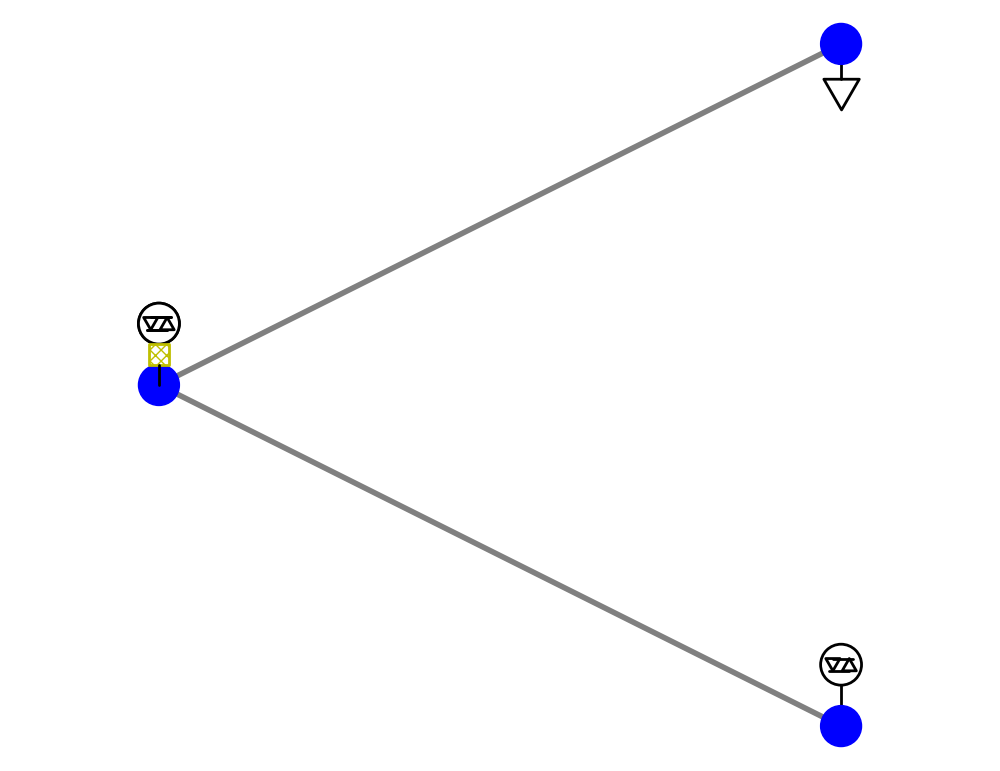

<Axes: >

In [33]:
# Create an empty network
net4 = pp.create_empty_network()

# Set base values for the per unit system
base_kV = 110 # Base voltage in kV
base_MVA = 110  # Base aparrent power

#Create the buses
bus1 = pp.create_bus(net4, vn_kv=base_kV, name="Bus 1")
bus2 = pp.create_bus(net4, vn_kv=base_kV, name="Bus 2")
bus3 = pp.create_bus(net4, vn_kv=base_kV, name="Bus 3")

#Create External grid (as the slack bus)
ext=pp.create_ext_grid(net4, bus1, min_p_mw=-0.5*base_MVA, max_p_mw=0.5*base_MVA)

#Create the generators
sgen1 = pp.create_sgen(net4, bus=bus1, p_mw=0, q_mvar=0, min_p_mw=0, max_p_mw=base_MVA, controllable=False, name="Solar")
sgen2 = pp.create_sgen(net4, bus=bus1, p_mw=0, q_mvar=0, min_p_mw=0, max_p_mw=base_MVA, controllable=False, name="Wind")
sgen3 = pp.create_sgen(net4, bus=bus2, p_mw=0, q_mvar=0.5*base_MVA, min_p_mw=0, max_p_mw=base_MVA, controllable=True, name="Gas Generator")

# Add generator costs
pp.create_poly_cost(net4, element=sgen3, et='sgen', cp1_eur_per_mw=80)

# Create the load
pp.create_load(net4, bus=bus3, p_mw=2*base_MVA, q_mvar=0.5*base_MVA, name="Load")

# Add storage to bus 3. We assume it starts out with no charge and can store up to 1/2 of base power.
storage_idx = pp.create_storage(net4, bus=bus3, p_mw=0, max_e_mwh=0.5*base_MVA, soc_percent=0, min_p_mw=-0.5*base_MVA, max_p_mw=0.5*base_MVA, controllable=True)

# Line setup
z_base = base_kV**2 / base_MVA  # in Ohms
r_ohm = 0.001*z_base
x_ohm = 0.01*z_base
length_km = 1  # nominal length

# Create the specific line used in Example 4
example4_line = {"r_ohm_per_km": r_ohm, "x_ohm_per_km": x_ohm, "c_nf_per_km": 10, "max_i_ka": 0.4, "type": "cs"}
pp.create_std_type(net4, name="example4_line", data=example4_line, element="line")
pp.create_line(net4, from_bus=bus1, to_bus=bus2, length_km=length_km, std_type="example4_line", name="line12")
pp.create_line(net4, from_bus=bus1, to_bus=bus3, length_km=length_km, std_type="example4_line", name="line13")

#Show the Example 4 grid
plot.simple_plot(net4, show_plot=True, plot_loads=True, plot_sgens=True, sgen_size =3, load_size=3, line_width=4, bus_size=3)

### 4b. Import and inspect time series
Let's have a look at the data we will use for the demand and the solar power of the day.



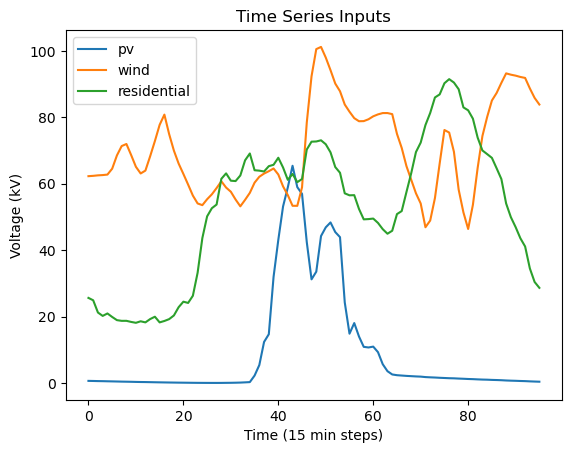

In [34]:
df = pd.read_json("data/time_series_15min.json")
df.loc[:, ['pv','wind','residential']].plot()
plt.title("Time Series Inputs")
plt.xlabel("Time (15 min steps)")
plt.ylabel("Voltage (kV)")
plt.show()

#### Question 4.1 | What did you notice?

Demand tends to peak at night when there's lack of solar power. Wind power is available throughout the day and night (depending on the weather).

### 4c. Create objective functions, add constraints, and optimize.
We will transfer our grid to **PICOS**  and create the objective function. We will create the variables pv_curtail and wind_curtail just to limit input from solar and wind farm when we don't have capacity to store all of it. For our grid, the battery already functions as a slack bus that helps to balance power flow, and our energy outputs seem sufficient for our demand. Let's leave out the external grid for now to see if our grid can operate "off the grid".


In [37]:
# Setup time variables
T = 96  # 96 steps for 24 hours (15 min each)
time_steps = np.arange(T)

# Extract admittance matrix for OPF (We first need to run an OPF once to generate Ybus. Note that we only want real-valued admittance)
pp.runpp(net4, calculate_voltage_angles=True)
Ybus_full = net4._ppc["internal"]["Ybus"].todense()
Ybus = np.real(Ybus_full)

# Generator and load mappings
gen_buses = list(net4.sgen.bus.values)
load_buses = list(net4.load.bus.values)
ext_grid_buses = list(net4.ext_grid.bus.values)
storage_bus = net4.storage.bus.at[storage_idx]

# Generator costs
gen_costs = list(net4.poly_cost.cp1_eur_per_mw.values)

# Variables
var_shapes = {
    "Pg": len(gen_buses),
    "Pch": 1,
    "Pdis": 1,
    "E": 1,
    "Theta": len(net4.bus),
    "pv_curtail": 1,
    "wind_curtail": 1
}

# Initialize variables
vars = {name: [] for name in var_shapes}

# Create variables
for t in range(T):
    for name, size in var_shapes.items():
        vars[name].append(pic.RealVariable(f"{name}_{t}", size))

Pg = [pic.RealVariable(f"Pg_{t}", len(gen_buses)) for t in range(T)] #Conrollable generators' power
Pch = [pic.RealVariable(f"Pch_{t}", 1) for t in range(T)] #Battery charging powers
Pdis = [pic.RealVariable(f"Pdis_{t}", 1) for t in range(T)] #Battery discharging powers
E = [pic.RealVariable(f"E_{t}", 1) for t in range(T)] #Battery state of Energy
Theta = [pic.RealVariable(f"Theta_{t}", len(net4.bus)) for t in range(T)] #Voltage angles
pv_curtail = [pic.RealVariable(f"pv_curtail_{t}", 1) for t in range(T)] #additional variable to control solar output
wind_curtail = [pic.RealVariable(f"wind_curtail_{t}", 1) for t in range(T)]  #additional variable to control wind output

# Battery Parameters
eta_ch = 0.95 #charging efficiency
eta_dis = 0.95 #discharging efficiency
c_deg = 10 #battery degradation cost in pound per MWh for charging or discharging
max_e_mwh = net4.storage.max_e_mwh.at[storage_idx]
Pch_max = net4.storage.max_p_mw.at[storage_idx]
Pdis_max = net4.storage.max_p_mw.at[storage_idx]

# Setup optimization model
prob = pic.Problem()

# Objective function components
gen_cost_vector = pic.Constant("gen_cost_vector", np.array(gen_costs)) #we need to convert the cost list to a PICOs vector for matrix multiplication
gen_cost_term = pic.sum([gen_cost_vector | vars["Pg"][t] for t in range(T)]) #| in PICOS is the same as @, matrix multiplication
storage_deg_cost = pic.sum([c_deg * (vars["Pch"][t][0] + vars["Pdis"][t][0]) for t in range(T)])

# Objective function
prob.set_objective("min", gen_cost_term + storage_deg_cost)

# Constraints
for t in range(T):
    # Power balance constraint
    load = df['residential'].values[t]
    pv_gen = df['pv'].values[t]
    wind_gen = df['wind'].values[t]
    injections = pic.sum(vars["Pg"][t])  + (pv_gen - vars["pv_curtail"][t]) + (wind_gen - vars["wind_curtail"][t]) + vars["Pdis"][t] - vars["Pch"][t]
    prob.add_constraint(injections == load)

    #Line flow constraints
    flow_limit = 100 * base_MVA / base_kV  # Set line limit appropriately

    for line_idx in net4.line.index:
        # Get from and to buses for the line
        from_bus = net4.line.at[line_idx, "from_bus"]
        to_bus = net4.line.at[line_idx, "to_bus"]
    
        # Line flow is 1/x_ij * (theta_from - theta_to)
        line_flow = 1/(x_ohm*length_km) * (vars["Theta"][t][from_bus] - vars["Theta"][t][to_bus])
    
        # Add line flow constraints
        prob.add_constraint(line_flow >= -flow_limit)
        prob.add_constraint(line_flow <= flow_limit)

    # Generator limits
    prob.add_constraint(0 <= vars["Pg"][t])
    prob.add_constraint(vars["Pg"][t] <= 110)
    prob.add_constraint(0 <= (pv_gen - vars["pv_curtail"][t]))
    prob.add_constraint(0 <= (wind_gen - vars["wind_curtail"][t]))
    
    # Storage charge/discharge limits
    prob.add_constraint(0 <= vars["Pch"][t])
    prob.add_constraint(vars["Pch"][t] <= Pch_max)
    prob.add_constraint(0 <= vars["Pdis"][t])
    prob.add_constraint(vars["Pdis"][t] <= Pdis_max)

    #Wind and solar curtailment cannot be negative
    prob.add_constraint(0 <= vars["pv_curtail"][t])
    prob.add_constraint(0 <= vars["wind_curtail"][t])
        
    # Storage energy dynamics
    if t == 0:
        prob.add_constraint(vars["E"][t] == 0)
        prob.add_constraint(vars["Pdis"][t] == 0)
        continue
    else:
        #We multiply the 0.25 (15 min/1hr = 0.25) to transform the unit to MWh. 
        prob.add_constraint(vars["E"][t] == vars["E"][t-1] + eta_ch * vars["Pch"][t] * 0.25 - (1/eta_dis) * vars["Pdis"][t] * 0.25)
    prob.add_constraint(0 <= vars["E"][t])
    prob.add_constraint(vars["E"][t] <= max_e_mwh)

# Solve 
prob.solve(verbosity=True)

print("Optimization completed.")

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


            PICOS 2.6.0            
Problem type: Linear Program.
Searching a solution strategy.
Solution strategy:
  1. ExtraOptions
  2. GurobiSolver
Applying ExtraOptions.
Building a Gurobi problem instance.
Set parameter Username
Academic license - for non-commercial use only - expires 2025-06-24
Starting solution search.
Set parameter FeasibilityTol to value 1e-08
Set parameter OptimalityTol to value 1e-08
Set parameter BarQCPConvTol to value 1e-10
Set parameter MIPGapAbs to value 1e-06
Set parameter QCPDual to value 1
-----------------------------------
         Gurobi Optimizer          
-----------------------------------
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (mac64[x86] - Darwin 22.5.0 22F82)

CPU model: Intel(R) Core(TM) i9-9880H CPU @ 2.30GHz
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 2111 rows, 1056 columns and 3356 nonzeros
Model fingerprint: 0xb34a1619
Coefficient statistics:
  Matrix range     [2e-01, 1

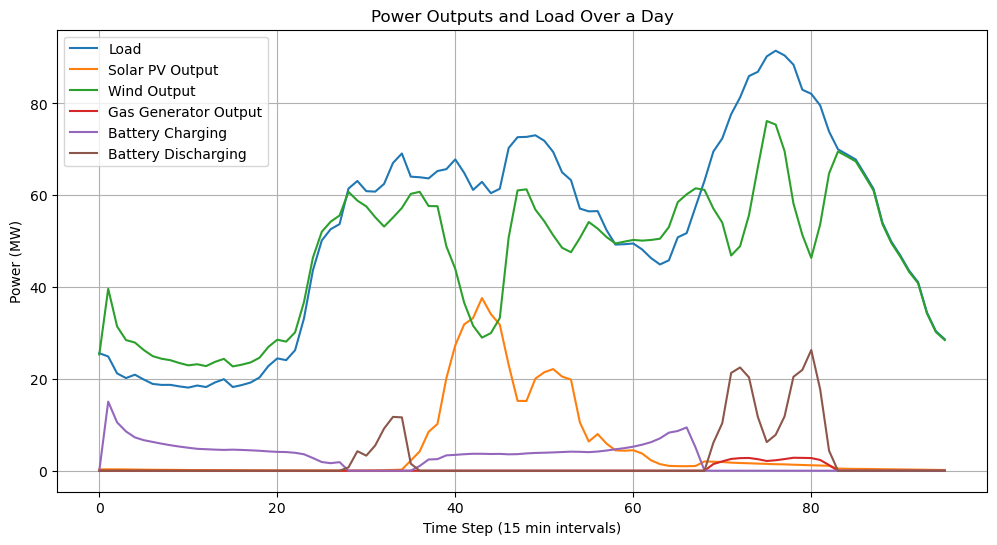

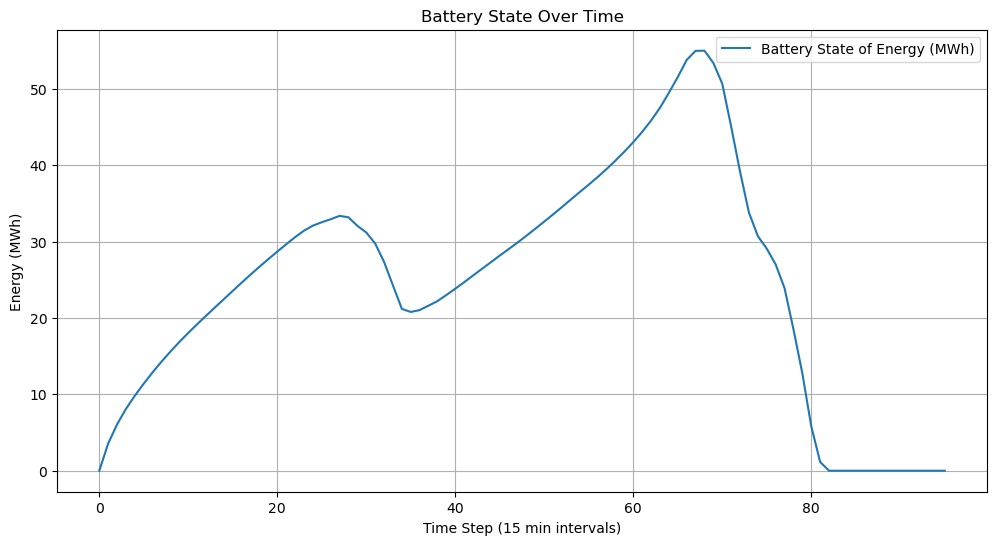

In [287]:
# Plot results

# Create storage for values
Pg_values = []
Pch_values = []
Pdis_values = []
E_values = []
pv_curtail_values = []
wind_curtail_values = []

# Load all values in one loop
for t in range(T):
    Pg_values.append(vars["Pg"][t].value)
    Pch_values.append(vars["Pch"][t].value)
    Pdis_values.append(vars["Pdis"][t].value)
    E_values.append(vars["E"][t].value)
    pv_curtail_values.append(vars["pv_curtail"][t].value)
    wind_curtail_values.append(vars["wind_curtail"][t].value)

# Convert lists to arrays
Pg_values = np.array(Pg_values).reshape(T, -1)
Pch_values = np.array(Pch_values)
Pdis_values = np.array(Pdis_values)
E_values = np.array(E_values)
pv_curtail_values = np.array(pv_curtail_values)
wind_curtail_values = np.array(wind_curtail_values)


# Actual renewable generations
pv_actual = df['pv'].values - pv_curtail_values
wind_actual = df['wind'].values - wind_curtail_values
load = df['residential'].values


plt.figure(figsize=(12,6))
plt.plot(time_steps, load, label="Load")
plt.plot(time_steps, pv_actual, label="Solar PV Output")
plt.plot(time_steps, wind_actual, label="Wind Output")
plt.plot(time_steps, Pg_values[:,1], label="Gas Generator Output")
plt.plot(time_steps, Pch_values, label="Battery Charging")
plt.plot(time_steps, Pdis_values, label="Battery Discharging")
plt.xlabel("Time Step (15 min intervals)")
plt.ylabel("Power (MW)")
plt.title("Power Outputs and Load Over a Day")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(time_steps, E_values, label="Battery State of Energy (MWh)")
plt.xlabel("Time Step (15 min intervals)")
plt.ylabel("Energy (MWh)")
plt.title("Battery State Over Time")
plt.legend()
plt.grid(True)
plt.show()

#### Question 4.2 | What did you observe throughout the day?

Battery is charged whenever demand is low and used to meet high demand periods, especially when there's no sun.

#### Question 4.3 | Try changing the cost of battery charging as well as the cost of gas generation.  What did you observe?

Our cost of battery usage is already cheaper than gas generation, and the abundance of wind and solar allows us to keep the use of gas generator at a minimum. When the opposite is true, we encourage the use of gas generator as a cheaper source of electricity. 

### 4d. Add Import and Export Cost
We have come a long way since our first example. Well done! Lastly, just for fun, let's connect back to the external grid and add a real-time pricing data as the cost for exporting/import electricity. For simplicity, we will assume that exporting and importing electricity cost the same. Let's take a look at our price data:


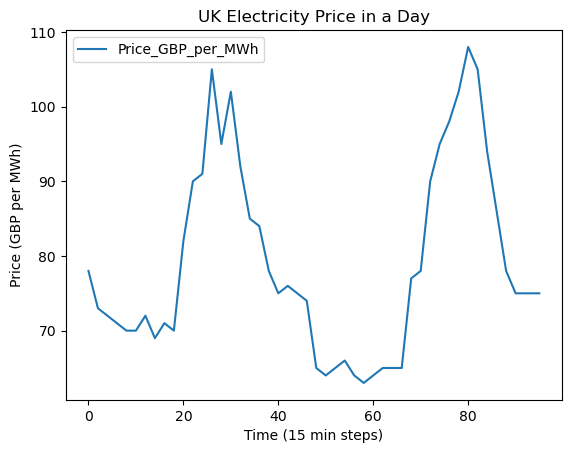

In [40]:
#import the data: 
df_e = pd.read_csv("data/UK_15-min_Price_Data.csv")
df_e.loc[:, ['Price_GBP_per_MWh']].plot()
plt.title("UK Electricity Price in a Day")
plt.xlabel("Time (15 min steps)")
plt.ylabel("Price (GBP per MWh)")
plt.show()

#### Question 4.4 | What variable do we need and what changes should we make to the objective function and constraints?

We should have one variable per time step, Pgrid[t], that allows both import and export, with a time varying cost coefficient c_e[t] that corresponds to the price so that c[t]Pgrid[t] will correspond to the cost/value of external grid interaction. We should also have an additional constraint for Pgrid[t] that limits it to our set value.

#### Question 4.5 | Using what you learned so far, add the import and export cost and optimize.

In [42]:
#EXTRACT THE PRICE DATA
c_e = df_e['Price_GBP_per_MWh'].values  

#DEFINE EXTERNAL GRID VARIABLE TO BE OPTIMIZED
Pgrid = [pic.RealVariable(f"Pgrid_{t}", 1) for t in range(T)]


# Setup optimization model
prob = pic.Problem()

# Objective function components
gen_cost_vector = pic.Constant("gen_cost_vector", np.array(gen_costs)) #we need to convert the cost list to a PICOs vector for matrix multiplication
gen_cost_term = pic.sum([gen_cost_vector | vars["Pg"][t] for t in range(T)]) #| in PICOS is the same as @, matrix multiplication
storage_deg_cost = pic.sum([c_deg * (vars["Pch"][t][0] + vars["Pdis"][t][0]) for t in range(T)])
#ADD EXTERNAL GRID COST
ext_grid_cost = pic.sum([c_e[t] * Pgrid[t] for t in range(T)])


# Objective function
prob.set_objective("min", gen_cost_term + storage_deg_cost + ext_grid_cost)

# Constraints
for t in range(T):
    # Power balance constraint
    load = df['residential'].values[t]
    pv_gen = df['pv'].values[t]
    wind_gen = df['wind'].values[t]
    #ADD EXTERNAL GRID VARIABLE TO POWER BALANCE CONSTRAINT
    injections = pic.sum(vars["Pg"][t])  + (pv_gen - vars["pv_curtail"][t]) + (wind_gen - vars["wind_curtail"][t]) + vars["Pdis"][t] - vars["Pch"][t] + Pgrid[t]
    prob.add_constraint(injections == load)

    #Line flow constraints
    flow_limit = 100 * base_MVA / base_kV  # Set line limit appropriately

    for line_idx in net4.line.index:
        # Get from and to buses for the line
        from_bus = net4.line.at[line_idx, "from_bus"]
        to_bus = net4.line.at[line_idx, "to_bus"]
    
        # Line flow is 1/x_ij * (theta_from - theta_to)
        line_flow = 1/(x_ohm*length_km) * (vars["Theta"][t][from_bus] - vars["Theta"][t][to_bus])
    
        # Add line flow constraints
        prob.add_constraint(line_flow >= -flow_limit)
        prob.add_constraint(line_flow <= flow_limit)

    # Generator limits
    prob.add_constraint(0 <= vars["Pg"][t])
    prob.add_constraint(vars["Pg"][t] <= 110)
    prob.add_constraint(0 <= (pv_gen - vars["pv_curtail"][t]))
    prob.add_constraint(0 <= (wind_gen - vars["wind_curtail"][t]))

    #External Grid Limit
    prob.add_constraint(-0.5*base_MVA <= Pgrid[t])
    prob.add_constraint(Pgrid[t] <= 0.5*base_MVA)
    
    # Storage charge/discharge limits
    prob.add_constraint(0 <= vars["Pch"][t])
    prob.add_constraint(vars["Pch"][t] <= Pch_max)
    prob.add_constraint(0 <= vars["Pdis"][t])
    prob.add_constraint(vars["Pdis"][t] <= Pdis_max)

    #Wind and solar curtailment cannot be negative
    prob.add_constraint(0 <= vars["pv_curtail"][t])
    prob.add_constraint(0 <= vars["wind_curtail"][t])

    # Storage energy dynamics
    if t == 0:
        prob.add_constraint(vars["E"][t] == 0)
        prob.add_constraint(vars["Pdis"][t] == 0)
        continue
    else:
        #We multiply the 0.25 (15 min/1hr = 0.25) to transform the unit to MWh. 
        prob.add_constraint(vars["E"][t] == vars["E"][t-1] + eta_ch * vars["Pch"][t] * 0.25 - (1/eta_dis) * vars["Pdis"][t] * 0.25)
    prob.add_constraint(0 <= vars["E"][t])
    prob.add_constraint(vars["E"][t] <= max_e_mwh)

# Solve 
prob.solve(verbosity=True)

print("Optimization completed.")


            PICOS 2.6.0            
Problem type: Linear Program.
Searching a solution strategy.
Solution strategy:
  1. ExtraOptions
  2. GurobiSolver
Applying ExtraOptions.
Building a Gurobi problem instance.
Starting solution search.
Set parameter FeasibilityTol to value 1e-08
Set parameter OptimalityTol to value 1e-08
Set parameter BarQCPConvTol to value 1e-10
Set parameter MIPGapAbs to value 1e-06
Set parameter QCPDual to value 1
-----------------------------------
         Gurobi Optimizer          
-----------------------------------
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (mac64[x86] - Darwin 22.5.0 22F82)

CPU model: Intel(R) Core(TM) i9-9880H CPU @ 2.30GHz
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 2303 rows, 1152 columns and 3644 nonzeros
Model fingerprint: 0xf46bd6a2
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [1e+01, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range      

#### Question 4.6 | Plot the resulting power outputs including external import/export, as well as the battery usage.

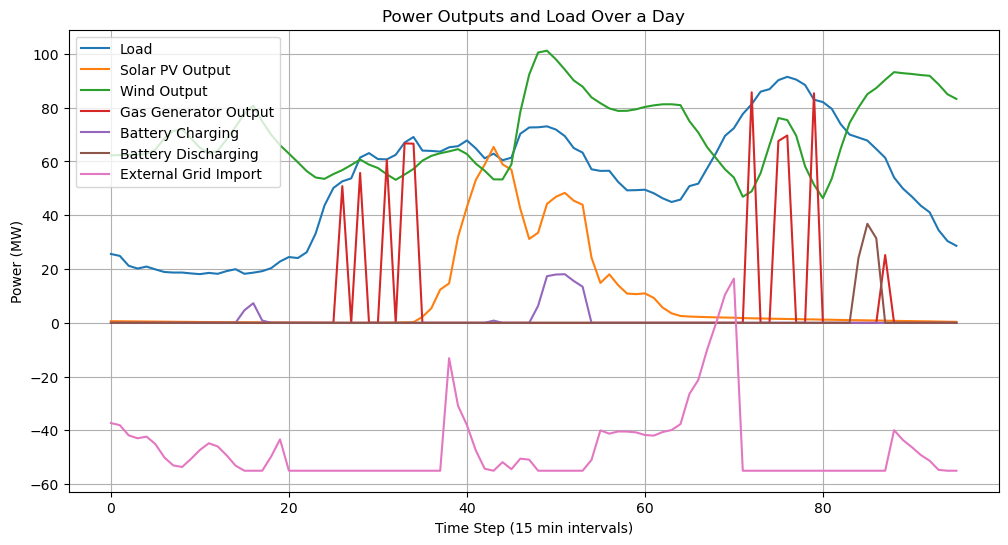

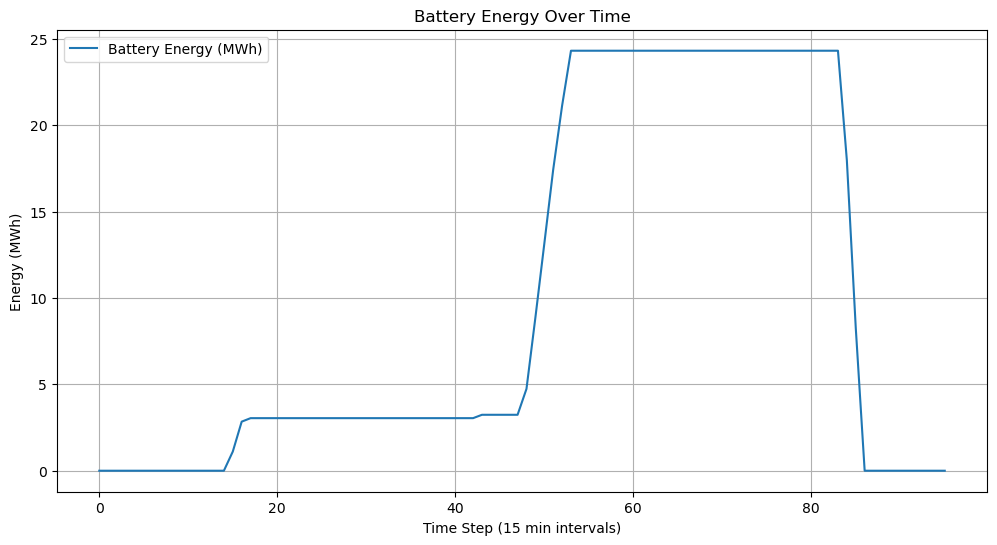

In [43]:
# Plot results

# Create storage for values
Pg_values = []
Pch_values = []
Pdis_values = []
E_values = []
Pgrid_values = []
pv_curtail_values = []
wind_curtail_values = []

# Load all values in one loop
for t in range(T):
    Pg_values.append(vars["Pg"][t].value)
    Pch_values.append(vars["Pch"][t].value)
    Pdis_values.append(vars["Pdis"][t].value)
    E_values.append(vars["E"][t].value)
    Pgrid_values.append(Pgrid[t].value)
    pv_curtail_values.append(vars["pv_curtail"][t].value)
    wind_curtail_values.append(vars["wind_curtail"][t].value)

# Convert lists to arrays
Pg_values = np.array(Pg_values).reshape(T, -1)
Pch_values = np.array(Pch_values)
Pdis_values = np.array(Pdis_values)
E_values = np.array(E_values)
Pgrid_values = np.array(Pgrid_values)
pv_curtail_values = np.array(pv_curtail_values)
wind_curtail_values = np.array(wind_curtail_values)


# Actual renewable generations
pv_actual = df['pv'].values - pv_curtail_values
wind_actual = df['wind'].values - wind_curtail_values
load = df['residential'].values


plt.figure(figsize=(12,6))
plt.plot(time_steps, load, label="Load")
plt.plot(time_steps, pv_actual, label="Solar PV Output")
plt.plot(time_steps, wind_actual, label="Wind Output")
plt.plot(time_steps, Pg_values[:,1], label="Gas Generator Output")
plt.plot(time_steps, Pch_values, label="Battery Charging")
plt.plot(time_steps, Pdis_values, label="Battery Discharging")
plt.plot(time_steps, Pgrid_values, label="External Grid Import")
plt.xlabel("Time Step (15 min intervals)")
plt.ylabel("Power (MW)")
plt.title("Power Outputs and Load Over a Day")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(time_steps, E_values, label="Battery Energy (MWh)")
plt.xlabel("Time Step (15 min intervals)")
plt.ylabel("Energy (MWh)")
plt.title("Battery Energy Over Time")
plt.legend()
plt.grid(True)
plt.show()

#### Question 4.7 | What did you observe?



Since selling electricity is profitable, the solver tries to sell for most of the time. Most of the electricity sold comes from the gas generator, but the solver also sold wind and solar electricity when they are most abundant. The solver also charged up the battery during this time and sold the electricity to the grid later on at night when the demand is the highest.

#### Question 4.8 | In this example, we have set the cost of gas generator to 80 GBP per MWh. Try setting the cost of gas generator to 30 GBP per MWh and see what happens. What if you increase the limit on how much you can import/export to the grid?

The gas generator ends up running more, and if selling to the grid is always possible and profitable, it will run to sell as much electricity to the grid as possible. When we increase the external grid limit beyond a certain point, the solver no longer utilizes the battery because it doesn't have much of an incentives to do so.

#### Question 4.9 | If you are a policy maker who has pushed for renewable development that built the wind and solar farm we use, what can you do to encourage renewable generation and discourage high-emission electricity?

I would levy a significant carbon tax on gas-generated electricity. You can do it yourself by increasing the cost coefficient of the gas generator. We can actually see exactly how much carbon tax we need to levy by varying the cost coefficient of the gas generator until we keep gas generation under a limit that we wish to set to keep gas-generated electricity below a certain percentage.